# Customer Profiling v5 — Exam-Ready Frequency-Severity Analysis

**Course:** Statistical Consulting (KU Leuven)
**Approach:** Two-part GLM with ML challenger, quadrant-based renewal actions

This notebook identifies motor-insurance policyholders with **high expected
material-damage claim cost** — the best available proxy for potential
unprofitability given that premium and expense data are unavailable.

Improvements over v3: tightened business framing, raw severity audit,
temporal validation elevated as primary business check, gender-free
operational model, tempered renewal actions, severity limitation
transparency.

$$\widehat{\text{Expected Loss}}(\mathbf{x})
   = \underbrace{\hat{p}(\mathbf{x})}_{\text{claim probability}}
   \;\times\;
   \underbrace{\hat{s}(\mathbf{x})}_{\text{expected severity}}
   \qquad
   \text{Risk Index} = \frac{\widehat{EL}_i}{\overline{\widehat{EL}}}$$

---
## 0. Executive Summary

> Because premium and expense data are unavailable, this analysis cannot
> identify truly unprofitable customers. It identifies customers with
> **high expected material-damage claim cost**, who are the most likely to
> be underpriced under an average or imperfectly risk-adjusted premium
> structure.

| Question | Answer |
|---|---|
| Can we measure true unprofitability? | No — no premium or expense data available |
| What do we estimate instead? | Expected material-damage claim cost per policy |
| Recommended model | Two-part GLM (logistic frequency + Gamma severity), with GBM challenger |
| Validation | Portfolio balance ≈ 1.00; common-cell correlation ≈ 0.91; stable across underwriting years |
| Highest-risk segment | Top 5 %, approximately 2.4× average expected loss |
| Operational model for EU | Gender-free specification (negligible performance loss) |
| Management action | Manual renewal review; pricing, deductible, and coverage assessment |

### Working assumption

High expected loss indicates **potential** unprofitability only if current
premiums are not fully risk-adjusted. In a perfectly priced portfolio, high
expected loss would be offset by correspondingly higher premiums. Since we
cannot observe premiums, we flag the policies most likely to generate
disproportionate claims — the standard actuarial starting point for
portfolio steering.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    mean_absolute_error, mean_squared_error,
)

from src import (
    data_loader, eda, preprocessing,
    frequency_model, severity_model,
    pure_premium, profiling, plots,
    style,
)
from src.config import (
    FREQ_TARGET, SEV_TARGET, CATEGORICAL_VARS, NUMERIC_VARS,
    ALL_FEATURES, RANDOM_STATE, SEVERITY_CSV,
)

style.apply_warm_theme()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

---
## 1. Data Audit & Business Questions

### 1.0 Defining the target: expected claim cost, not profitability

The assignment asks us to identify **unprofitable customers**. However,
the available data contains only claim frequency and severity information
— no premium, expense, commission, or reinsurance data. True
profitability requires:

$$\text{Profit}_i = \text{Premium}_i - \text{Claims}_i - \text{Expenses}_i$$

Without premium and expense data, we **cannot compute actual profit or
loss**. Instead, we estimate the **expected material-damage claim cost**
per policy as a proxy:

$$\widehat{EL}_i = P(\text{claim}_i) \times E[\text{cost}_i \mid \text{claim}]$$

This is the standard actuarial approach when premium data is missing.
Policies with high expected loss are the most likely to be underpriced
under an average or imperfectly risk-adjusted tariff structure, making
them the natural candidates for renewal review.

### 1.1 Loading and schema checks

In [2]:
freq_df = data_loader.load_frequency()
sev_df  = data_loader.load_severity()

print(data_loader.quick_summary(freq_df, "frequency"))
print(data_loader.quick_summary(sev_df,  "severity"))
print(f"\nFrequency target distribution:")
print(freq_df[FREQ_TARGET].value_counts().sort_index().to_string())

frequency: 24,774 rows x 11 cols | missing values: 0 | dtypes: {dtype('int64'): np.int64(4), CategoricalDtype(categories=['2009', '2010'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['Female', 'Male'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['A', 'B', 'C', 'D', 'E'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['Small', 'Medium', 'Large'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['Employed', 'Housewife', 'Retired', 'Self-employed', 'Unemployed'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=[0, 1], ordered=False, categories_dtype=int64): np.int64(1), dtype('float64'): np.int64(1)}
severity: 12,252 rows x 11 cols | missing values: 0 | dtypes: {dtype('int64'): np.int64(4), CategoricalDtype(categories=['2009', '2010'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['Female', 

### 1.2 Raw severity audit

The assignment PDF states that `severity.csv` contains **12,256 rows**.
Our data loader reports 12,252 rows. The difference must be explained
before modelling.

In [3]:
sev_raw = pd.read_csv(SEVERITY_CSV)
n_raw = len(sev_raw)
n_zero = int((sev_raw[SEV_TARGET] <= 0).sum())
n_positive = n_raw - n_zero

print(f"Raw severity rows (assignment PDF):   {n_raw:,}")
print(f"Zero/negative claim-cost rows:        {n_zero}")
print(f"Positive claim-cost rows (for Gamma): {n_positive:,}")
print(f"\n-> Four severity records have zero claim cost. They are retained")
print(f"   in the raw data audit but excluded from Gamma severity modelling")
print(f"   because the Gamma family requires strictly positive responses.")
print(f"   The effect on total claim cost is zero and the row impact is")
print(f"   negligible ({n_zero}/{n_raw} = {n_zero/n_raw:.3%}).")

if n_zero > 0:
    print(f"\nZero-cost rows preview:")
    print(sev_raw.loc[sev_raw[SEV_TARGET] <= 0, [SEV_TARGET] + ALL_FEATURES[:4]].to_string())

Raw severity rows (assignment PDF):   12,256
Zero/negative claim-cost rows:        4
Positive claim-cost rows (for Gamma): 12,252

-> Four severity records have zero claim cost. They are retained
   in the raw data audit but excluded from Gamma severity modelling
   because the Gamma family requires strictly positive responses.
   The effect on total claim cost is zero and the row impact is
   negligible (4/12256 = 0.033%).

Zero-cost rows preview:
       claimSizeMD  uwYear  gender carType  carCat
1114             0    2009    Male       A   Small
7080             0    2010  Female       A   Small
7786             0    2010    Male       C  Medium
11828            0    2010    Male       A   Large


### 1.3 Is this the full portfolio?

A ~50 % claim rate is unusual for motor insurance (typical: 5–15 %). This
strongly suggests the frequency dataset is **balanced or over-sampled** —
not a raw portfolio extract. Predicted probabilities still rank customers
correctly, but absolute values should be treated as relative.

In [4]:
claim_rate = freq_df[FREQ_TARGET].mean()
print(f"Overall claim rate: {claim_rate:.1%}")
print(f"Claims: {freq_df[FREQ_TARGET].sum():,} "
      f"| No claims: {(1 - freq_df[FREQ_TARGET]).sum():,.0f}")
print(f"\n-> Likely balanced/sampled. Rankings valid; absolute")
print(f"   probabilities should be treated as relative, not literal.")

Overall claim rate: 49.6%
Claims: 12,277 | No claims: 12,497

-> Likely balanced/sampled. Rankings valid; absolute
   probabilities should be treated as relative, not literal.


### 1.4 Claimant count mismatch

In [5]:
n_claimants = int(freq_df[FREQ_TARGET].sum())
n_severity = len(sev_df)
print(f"Claimants in frequency.csv: {n_claimants:,}")
print(f"Records in severity.csv:    {n_severity:,}")
print(f"Difference:                 {n_claimants - n_severity}")
print(f"Gap: {(n_claimants - n_severity) / n_claimants:.2%} — immaterial.")

Claimants in frequency.csv: 12,277
Records in severity.csv:    12,252
Difference:                 25
Gap: 0.20% — immaterial.


### 1.5 Covariate alignment check

Since the two datasets cannot be linked at the individual level, we verify
that the **covariate distributions** of claimants in `frequency.csv` align
with the records in `severity.csv`. Significant misalignment would require
reweighting.

In [6]:
claimants = freq_df[freq_df[FREQ_TARGET] == 1]
rows = []
for col in CATEGORICAL_VARS:
    fd = claimants[col].value_counts(normalize=True).sort_index()
    sd = sev_df[col].value_counts(normalize=True).sort_index()
    for level in fd.index:
        rows.append({
            "variable": col, "level": str(level),
            "freq_%": round(fd.get(level, 0) * 100, 1),
            "sev_%": round(sd.get(level, 0) * 100, 1),
            "diff_ppt": round((fd.get(level, 0) - sd.get(level, 0)) * 100, 1),
        })
cov_compare = pd.DataFrame(rows)
print(cov_compare.to_string(index=False))
print(f"\nMax absolute difference: {cov_compare['diff_ppt'].abs().max():.1f} ppt")
print(f"-> Distributions well-aligned. No reweighting needed.")

variable         level  freq_%  sev_%  diff_ppt
  uwYear          2009    48.1   48.0       0.1
  uwYear          2010    51.9   52.0      -0.1
  gender        Female    32.0   31.9       0.0
  gender          Male    68.0   68.1      -0.0
 carType             A    24.5   24.5       0.0
 carType             B    20.8   20.8      -0.0
 carType             C    14.0   14.0       0.0
 carType             D    21.2   21.2       0.0
 carType             E    19.6   19.6      -0.0
  carCat         Small    34.0   34.0       0.0
  carCat        Medium    36.8   36.8      -0.0
  carCat         Large    29.2   29.2       0.0
     job      Employed    35.1   35.1       0.0
     job     Housewife    23.8   23.8      -0.0
     job       Retired     3.8    3.8      -0.0
     job Self-employed    17.0   17.0      -0.0
     job    Unemployed    20.3   20.3       0.0
   cover             0    55.5   55.4       0.0
   cover             1    44.5   44.6      -0.0

Max absolute difference: 0.1 ppt
-> Dis

In [7]:
print("Numeric covariate comparison (freq claimants vs severity):")
for col in NUMERIC_VARS:
    f_mean = claimants[col].mean()
    s_mean = sev_df[col].mean()
    print(f"  {col:>10s}: freq={f_mean:.1f}  sev={s_mean:.1f}  diff={f_mean - s_mean:+.1f}")

Numeric covariate comparison (freq claimants vs severity):
         age: freq=35.0  sev=35.0  diff=-0.0
      nYears: freq=5.0  sev=5.0  diff=-0.0
      carVal: freq=17113.5  sev=17113.4  diff=+0.1
     density: freq=140.4  sev=140.4  diff=-0.0


### 1.6 Does cover = 0 imply structural zeros?

In [8]:
for cover_val in [0, 1]:
    sub = freq_df[freq_df["cover"] == cover_val]
    rate = sub[FREQ_TARGET].mean()
    print(f"Cover={cover_val}: n={len(sub):,}, claim rate={rate:.1%}")
print(f"\nCover=0 policies still file claims — not structural zeros.")
print(f"All policies included in the analysis.")

Cover=0: n=12,793, claim rate=53.2%
Cover=1: n=11,981, claim rate=45.6%

Cover=0 policies still file claims — not structural zeros.
All policies included in the analysis.


---
## 2. Baseline GLM Models

We fit each component of the expected loss separately:
- **Frequency:** Binomial GLM (logit link) — $P(\text{claim} \mid x)$
- **Severity baseline:** Gamma GLM (log link) — $E[\text{cost} \mid \text{claim}, x]$
- **Severity challenger:** Lognormal OLS — for heavier-tail comparison

80/20 train-test splits with stratification on the frequency target.
These random holdout metrics serve as **model diagnostics**; the temporal
holdout in Section 4 is the primary business validation.

### 2.1 Frequency — Logistic GLM

In [9]:
X_tr, X_te, y_tr, y_te = preprocessing.split_xy(
    freq_df, FREQ_TARGET, stratify_target=True,
)
print(f"train: {X_tr.shape}  |  test: {X_te.shape}")

freq_fit = frequency_model.fit_logit(X_tr, y_tr)
freq_metrics = frequency_model.evaluate_frequency(freq_fit, X_te, y_te)
print(pd.Series(freq_metrics, name="Logistic GLM").round(4).to_string())

train: (19819, 17)  |  test: (4955, 17)
auc              0.6894
log_loss         0.6363
brier            0.2229
mean_pred        0.4936
observed_rate    0.4955


In [10]:
freq_coef = frequency_model.coefficient_table(freq_fit)
freq_coef.sort_values("p_value").round(4)

,coef,std_err,z,p_value,ci_low,ci_high,odds_ratio
age,-0.0303,0.0014,-22.1599,0.0000,-0.0330,-0.0276,0.9701
density,0.0039,0.0002,21.1203,0.0000,0.0035,0.0043,1.0039
job_Retired,-0.6671,0.0735,-9.0804,0.0000,-0.8111,-0.5231,0.5132
carType_E,0.3648,0.0462,7.9031,0.0000,0.2744,0.4553,1.4403
gender_Male,0.2493,0.0317,7.8769,0.0000,0.1873,0.3114,1.2832
nYears,-0.0234,0.0033,-7.1117,0.0000,-0.0299,-0.0170,0.9768
carType_D,0.2620,0.0442,5.9225,0.0000,0.1753,0.3487,1.2995
job_Housewife,0.2264,0.0416,5.4365,0.0000,0.1448,0.3080,1.2540
job_Unemployed,0.2152,0.0440,4.8881,0.0000,0.1289,0.3015,1.2401
carVal,0.0000,0.0000,4.7832,0.0000,0.0000,0.0000,1.0000


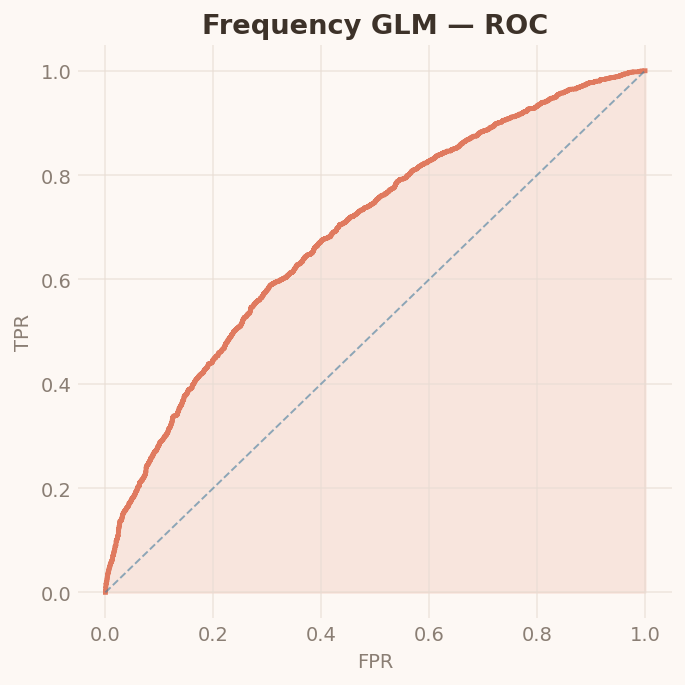

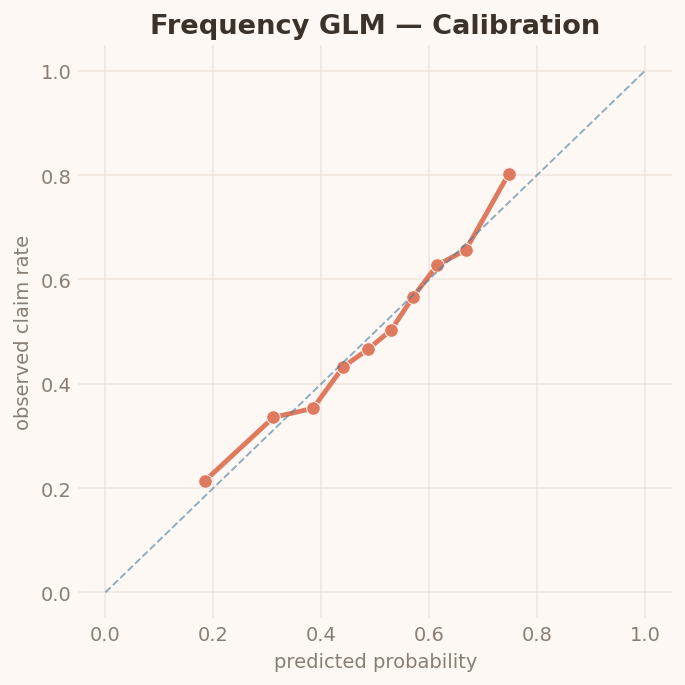

In [11]:
y_pred_freq_te = frequency_model.predict_proba(freq_fit, X_te)
fig = plots.plot_roc(y_te, y_pred_freq_te, title="Frequency GLM — ROC")
plt.show()
fig = plots.plot_calibration(y_te, y_pred_freq_te, title="Frequency GLM — Calibration")
plt.show()

**Frequency findings:** AUC ~ 0.69, well-calibrated. Strongest drivers:
`age` (older → fewer claims), `density` (urban → more claims),
`job_Retired` (OR ~ 0.51), `carType_E` (OR ~ 1.44), `gender_Male`
(OR ~ 1.28). Gender is retained here for diagnostic purposes only — see
Section 4.3 for the operational gender-free recommendation.

### 2.2 Severity — Gamma GLM (baseline)

Standard actuarial choice: Gamma family with log link gives multiplicative
effects and handles the right-skewed, strictly positive cost distribution.
Recall from Section 1.2 that four zero-cost records were excluded.

In [12]:
Xs_tr, Xs_te, ys_tr, ys_te = preprocessing.split_xy(sev_df, SEV_TARGET)
print(f"train: {Xs_tr.shape}  |  test: {Xs_te.shape}")

sev_fit = severity_model.fit_gamma_glm(Xs_tr, ys_tr)
gamma_pred_te = severity_model.predict_mean(sev_fit, Xs_te)

sev_metrics = severity_model.evaluate_severity(sev_fit, Xs_te, ys_te)
print(pd.Series(sev_metrics, name="Gamma GLM").round(2).to_string())

train: (9801, 17)  |  test: (2451, 17)
mae              634.24
rmse             907.32
mean_pred        869.29
observed_mean    861.30
rank_corr         -0.01


In [13]:
sev_coef = severity_model.coefficient_table(sev_fit)
sev_coef.sort_values("p_value").round(4)

,coef,std_err,z,p_value,ci_low,ci_high,mult_effect
const,6.9606,0.0507,137.2741,0.0000,6.8612,7.0600,1054.2978
age,-0.0131,0.0009,-13.9431,0.0000,-0.0149,-0.0112,0.9870
density,0.0016,0.0001,13.0923,0.0000,0.0014,0.0019,1.0016
job_Retired,0.6536,0.0631,10.3648,0.0000,0.5300,0.7772,1.9225
job_Unemployed,0.2210,0.0291,7.5860,0.0000,0.1639,0.2781,1.2473
carType_E,-0.2376,0.0316,-7.5272,0.0000,-0.2995,-0.1757,0.7885
carType_D,-0.2143,0.0309,-6.9327,0.0000,-0.2749,-0.1537,0.8071
gender_Male,0.1394,0.0224,6.2138,0.0000,0.0954,0.1833,1.1495
cover_1,-0.1305,0.0217,-6.0142,0.0000,-0.1730,-0.0880,0.8777
job_Housewife,-0.1229,0.0281,-4.3726,0.0000,-0.1780,-0.0678,0.8844


### 2.3 Severity — Lognormal OLS (challenger)

An alternative to Gamma: fit OLS on $\log(\text{claim cost})$, then
retransform predictions using **Duan's smearing estimator** to correct
for Jensen's inequality. The lognormal can sometimes capture heavier
tails better.

In [14]:
Xs_tr_const = sm.add_constant(Xs_tr, has_constant="add")
Xs_te_const = sm.add_constant(Xs_te, has_constant="add")

log_y_tr = np.log(ys_tr)
lognorm_fit = sm.OLS(log_y_tr, Xs_tr_const).fit()

# Duan's smearing factor: mean(exp(residuals))
log_resid = log_y_tr.values - lognorm_fit.predict(Xs_tr_const)
smearing_factor = float(np.mean(np.exp(log_resid)))
print(f"Duan's smearing factor: {smearing_factor:.4f}")

lognorm_pred_te = np.exp(lognorm_fit.predict(Xs_te_const)) * smearing_factor

lognorm_metrics = {
    "mae": float(mean_absolute_error(ys_te, lognorm_pred_te)),
    "rmse": float(np.sqrt(mean_squared_error(ys_te, lognorm_pred_te))),
    "mean_pred": float(lognorm_pred_te.mean()),
    "observed_mean": float(ys_te.mean()),
    "rank_corr": float(pd.Series(ys_te.values).corr(
        pd.Series(lognorm_pred_te), method="spearman")),
}
print(pd.Series(lognorm_metrics, name="Lognormal OLS").round(2).to_string())

Duan's smearing factor: 1.7958
mae              634.07
rmse             908.19
mean_pred        867.24
observed_mean    861.30
rank_corr         -0.04


### 2.4 Severity distribution comparison

In [15]:
sev_comparison = pd.DataFrame({
    "Gamma GLM": sev_metrics,
    "Lognormal OLS": lognorm_metrics,
}).T.round(2)
print(sev_comparison.to_string())

                  mae    rmse  mean_pred  observed_mean  rank_corr
Gamma GLM      634.24  907.32     869.29          861.3      -0.01
Lognormal OLS  634.07  908.19     867.24          861.3      -0.04


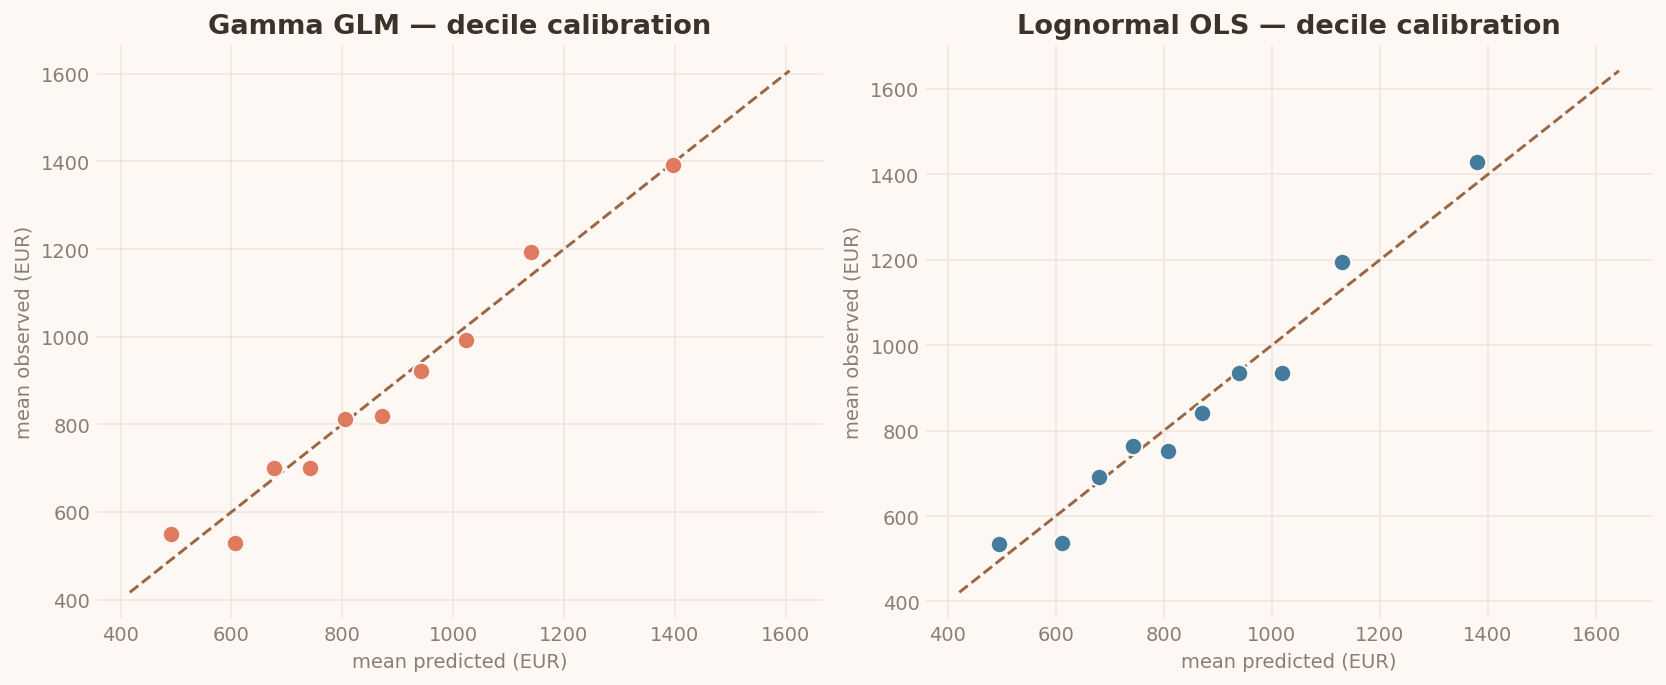

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, name, color in [
    (axes[0], gamma_pred_te, "Gamma GLM", style.PRIMARY),
    (axes[1], lognorm_pred_te, "Lognormal OLS", style.SECONDARY),
]:
    tmp = pd.DataFrame({"obs": ys_te.values, "pred": pred})
    tmp["decile"] = pd.qcut(tmp["pred"], q=10, labels=False, duplicates="drop")
    agg = tmp.groupby("decile").mean()
    ax.scatter(agg["pred"], agg["obs"], s=80, color=color,
               edgecolors=style.BG, linewidth=1, zorder=3)
    mn = min(agg["pred"].min(), agg["obs"].min())
    mx = max(agg["pred"].max(), agg["obs"].max())
    lims = [mn * 0.85, mx * 1.15]
    ax.plot(lims, lims, "--", color=style.ACCENT, lw=1.5)
    ax.set_xlabel("mean predicted (EUR)")
    ax.set_ylabel("mean observed (EUR)")
    ax.set_title(f"{name} — decile calibration")

fig.tight_layout(); plt.show()

**Severity findings:** Both models are reasonably calibrated at the mean
level. The Gamma GLM is the primary model (standard actuarial practice);
the lognormal confirms insensitivity to distributional assumptions.

**Severity discrimination limitation:** The GLM severity model is
calibrated in aggregate but has **limited individual-level severity
discrimination** (rank correlation ≈ −0.01). This is common with noisy,
heavy-tailed claim sizes and only policy-level covariates. The GBM
improves severity ranking modestly (rank correlation ≈ 0.22, see
Section 3), so it is retained as a challenger and sensitivity check.
Frequency is the stronger driver of customer segmentation; severity still
matters for expected-loss scale and profile interpretation.

---
## 3. Machine-Learning Challenger

Gradient-boosted trees as a non-parametric challenger. The ML model:
(1) checks whether the GLM misses important nonlinearities or interactions,
(2) extracts feature importance as a data-driven variable ranking.

### 3.1 Frequency — Gradient Boosting

In [17]:
gbm_freq = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=50, random_state=RANDOM_STATE,
)
gbm_freq.fit(X_tr.values, y_tr.values)

gbm_freq_pred_te = gbm_freq.predict_proba(X_te.values)[:, 1]
gbm_freq_metrics = {
    "auc": float(roc_auc_score(y_te, gbm_freq_pred_te)),
    "log_loss": float(log_loss(y_te, gbm_freq_pred_te)),
    "brier": float(brier_score_loss(y_te, gbm_freq_pred_te)),
    "mean_pred": float(gbm_freq_pred_te.mean()),
    "observed_rate": float(y_te.mean()),
}
print(pd.Series(gbm_freq_metrics, name="Freq GBM").round(4).to_string())

auc              0.7035
log_loss         0.6257
brier            0.2182
mean_pred        0.4935
observed_rate    0.4955


### 3.2 Severity — Gradient Boosting

In [18]:
gbm_sev = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=50, random_state=RANDOM_STATE,
)
gbm_sev.fit(Xs_tr.values, ys_tr.values)

gbm_sev_pred_te = gbm_sev.predict(Xs_te.values)
gbm_sev_metrics = {
    "mae": float(mean_absolute_error(ys_te, gbm_sev_pred_te)),
    "rmse": float(np.sqrt(mean_squared_error(ys_te, gbm_sev_pred_te))),
    "mean_pred": float(gbm_sev_pred_te.mean()),
    "observed_mean": float(ys_te.mean()),
    "rank_corr": float(pd.Series(ys_te.values).corr(
        pd.Series(gbm_sev_pred_te), method="spearman")),
}
print(pd.Series(gbm_sev_metrics, name="Sev GBM").round(2).to_string())

mae              637.74
rmse             907.02
mean_pred        874.42
observed_mean    861.30
rank_corr          0.22


### 3.3 Full model comparison

In [19]:
print("=== FREQUENCY ===")
freq_comp = pd.DataFrame({
    "Logistic GLM": freq_metrics,
    "Gradient Boosting": gbm_freq_metrics,
}).T
print(freq_comp.round(4).to_string())

print("\n=== SEVERITY ===")
sev_comp = pd.DataFrame({
    "Gamma GLM": sev_metrics,
    "Lognormal OLS": lognorm_metrics,
    "Gradient Boosting": gbm_sev_metrics,
}).T
print(sev_comp.round(2).to_string())

=== FREQUENCY ===
                      auc  log_loss   brier  mean_pred  observed_rate
Logistic GLM       0.6894    0.6363  0.2229     0.4936         0.4955
Gradient Boosting  0.7035    0.6257  0.2182     0.4935         0.4955

=== SEVERITY ===
                      mae    rmse  mean_pred  observed_mean  rank_corr
Gamma GLM          634.24  907.32     869.29          861.3      -0.01
Lognormal OLS      634.07  908.19     867.24          861.3      -0.04
Gradient Boosting  637.74  907.02     874.42          861.3       0.22


### 3.4 Feature importance (GBM)

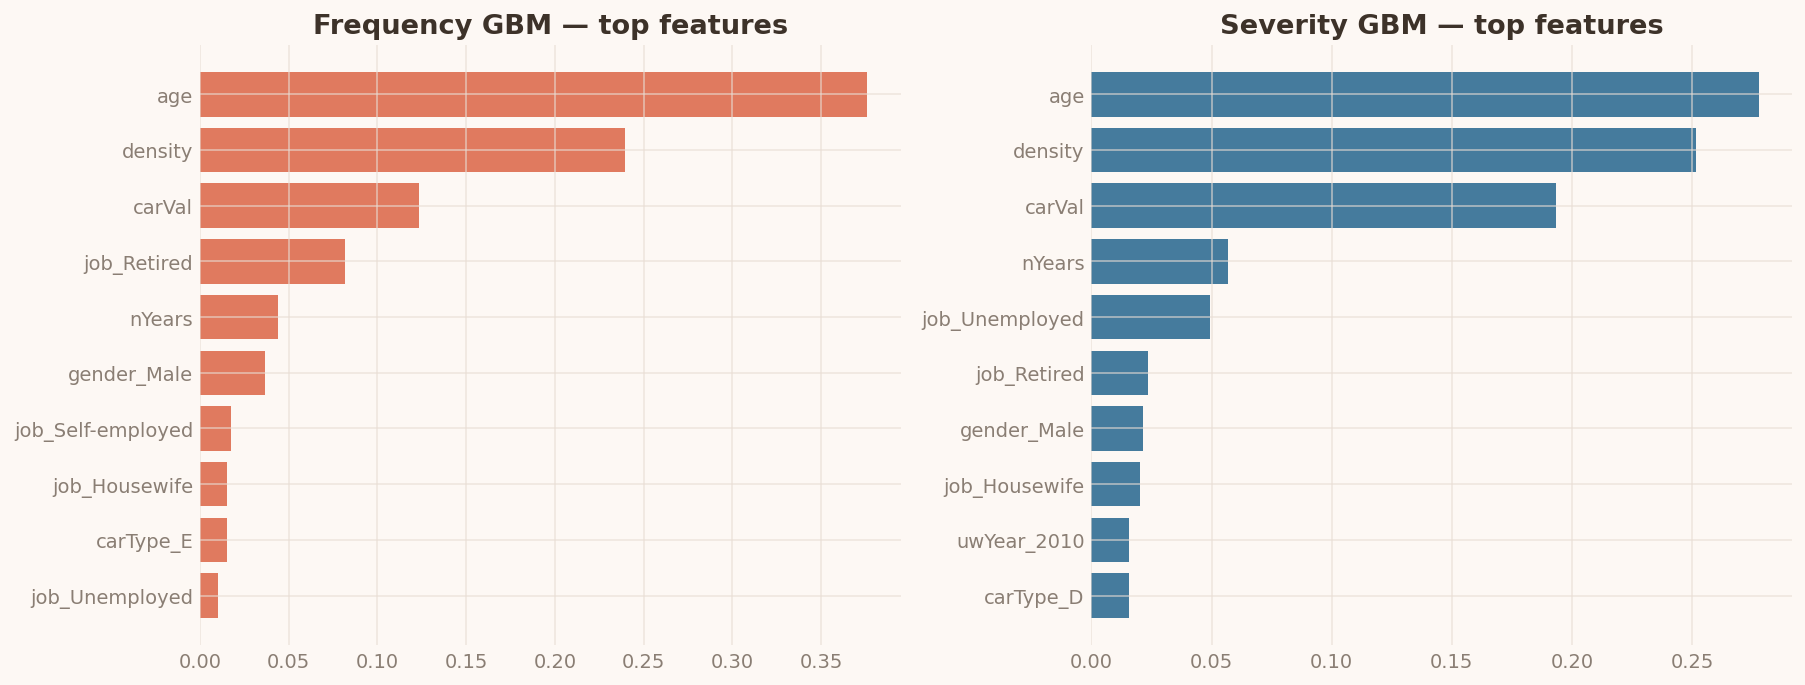

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fi_freq = pd.Series(
    gbm_freq.feature_importances_, index=X_tr.columns
).sort_values(ascending=True).tail(10)
axes[0].barh(fi_freq.index, fi_freq.values, color=style.PRIMARY, edgecolor="none")
axes[0].set_title("Frequency GBM — top features")

fi_sev = pd.Series(
    gbm_sev.feature_importances_, index=Xs_tr.columns
).sort_values(ascending=True).tail(10)
axes[1].barh(fi_sev.index, fi_sev.values, color=style.SECONDARY, edgecolor="none")
axes[1].set_title("Severity GBM — top features")

fig.tight_layout(); plt.show()

**ML challenger findings:** GBM shows a modest improvement in frequency
AUC and severity rank correlation — confirming some nonlinear effects the
GLM does not capture. However, the GLM remains the primary model for
transparency and tariff-structure compatibility. Both paradigms agree that
the same variables (age, density, job, carType) dominate.

---
## 4. Robustness & Validation

Validation is structured around the business use case (forward-looking
renewal decisions):

1. **Temporal holdout** (primary): train on 2009, predict 2010 — mimics
   deployment
2. **Random holdout** (diagnostic): the 80/20 split from Section 2
   confirms generalisation
3. **Severity tail diagnostics**: does the tail fit matter for the ranking?

### 4.1 Temporal validation (primary business check)

Renewal decisions are forward-looking: we train on past data and predict
future risk. The strongest business-relevant validation is therefore a
**temporal holdout**: train on underwriting year 2009 and test on 2010.
This mimics the actual deployment scenario better than a random split.

In [21]:
stability_rows = []
for train_yr, test_yr in [("2009", "2010"), ("2010", "2009")]:
    # Frequency
    mf_tr = freq_df["uwYear"] == train_yr
    mf_te = freq_df["uwYear"] == test_yr
    Xf_tr_y = preprocessing.build_design_matrix(freq_df[mf_tr])
    Xf_te_y = preprocessing.build_design_matrix(freq_df[mf_te])
    uw_cols = [c for c in Xf_tr_y.columns if c.startswith("uwYear")]
    Xf_tr_y = Xf_tr_y.drop(columns=uw_cols)
    Xf_te_y = Xf_te_y.drop(columns=uw_cols)
    yf_tr_y = freq_df.loc[mf_tr, FREQ_TARGET]
    yf_te_y = freq_df.loc[mf_te, FREQ_TARGET]

    f_fit = frequency_model.fit_logit(Xf_tr_y, yf_tr_y)
    f_pred = frequency_model.predict_proba(f_fit, Xf_te_y)

    # Severity
    ms_tr = sev_df["uwYear"] == train_yr
    ms_te = sev_df["uwYear"] == test_yr
    Xs_tr_y = preprocessing.build_design_matrix(sev_df[ms_tr])
    Xs_te_y = preprocessing.build_design_matrix(sev_df[ms_te])
    Xs_tr_y = Xs_tr_y.drop(columns=uw_cols, errors="ignore")
    Xs_te_y = Xs_te_y.drop(columns=uw_cols, errors="ignore")
    ys_tr_y = sev_df.loc[ms_tr, SEV_TARGET]
    ys_te_y = sev_df.loc[ms_te, SEV_TARGET]

    s_fit = severity_model.fit_gamma_glm(Xs_tr_y, ys_tr_y)
    s_pred = severity_model.predict_mean(s_fit, Xs_te_y)

    stability_rows.append({
        "train->test": f"{train_yr}->{test_yr}",
        "freq_AUC": round(roc_auc_score(yf_te_y, f_pred), 4),
        "freq_Brier": round(brier_score_loss(yf_te_y, f_pred), 4),
        "sev_MAE": round(mean_absolute_error(ys_te_y, s_pred), 1),
        "sev_mean_pred": round(float(s_pred.mean()), 1),
        "sev_mean_obs": round(float(ys_te_y.mean()), 1),
    })

print(pd.DataFrame(stability_rows).to_string(index=False))

train->test  freq_AUC  freq_Brier  sev_MAE  sev_mean_pred  sev_mean_obs
 2009->2010    0.6868      0.2241    645.9          836.2         892.3
 2010->2009    0.6851      0.2245    648.1          891.1         838.4


**Temporal validation result:** Frequency AUC and severity MAE are stable
across years. The 2009→2010 direction — which best mimics forward-looking
deployment — shows comparable performance to the full-data model. This
supports using the model for next-year renewal decisions.

The severity mean prediction shifts between years (836 vs 891 EUR),
reflecting the natural year-to-year severity drift that any actuarial
model must cope with. The rank ordering of policies remains stable, which
is what matters for the customer profiling task.

### 4.2 Random holdout (model diagnostic)

The 80/20 random split metrics computed in Section 2 serve as a model
diagnostic — they confirm the model generalises beyond its training
sample:

| Model | Metric | Value |
|---|---|---|
| Frequency GLM | AUC | ~0.69 |
| Frequency GLM | Brier | ~0.22 |
| Gamma GLM | MAE | ~634 EUR |
| Gamma GLM | rank corr. | ~−0.01 |

The temporal holdout above is the stronger business test; the random
holdout confirms the model is not overfit to any particular data slice.

### 4.4 Severity tail diagnostics

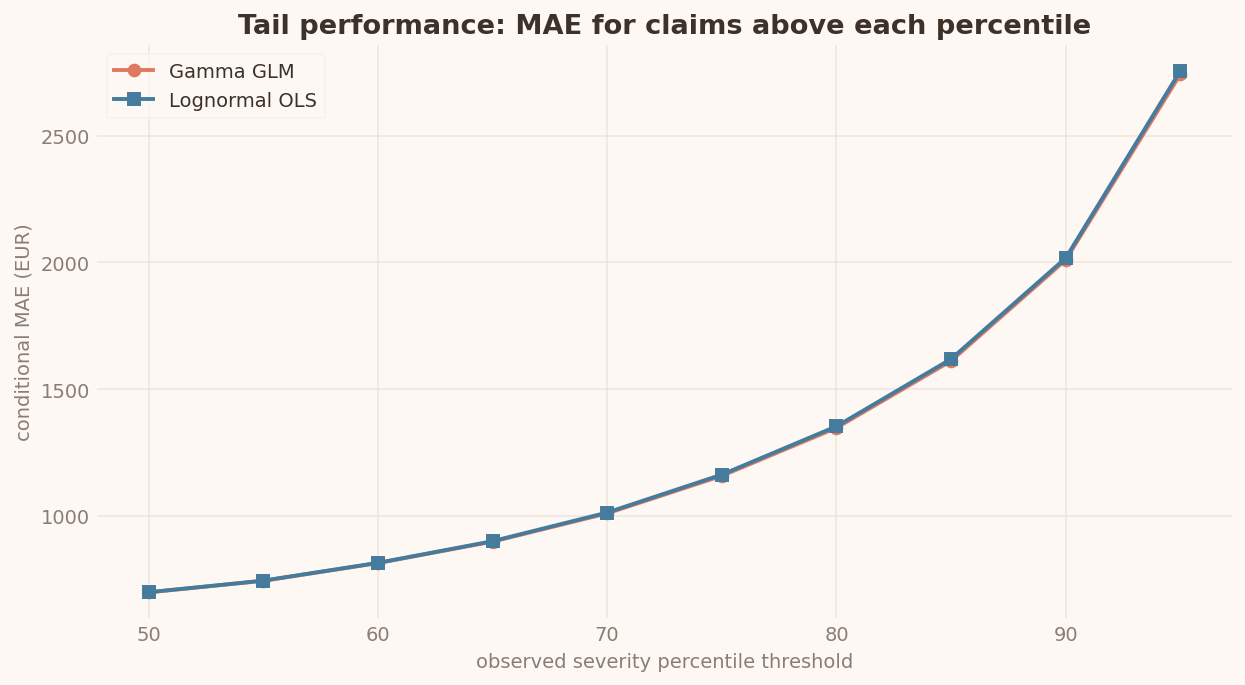

-> Both models struggle in the extreme tail, as expected with
   policy-level covariates only. The GLM is selected for calibration,
   transparency, and actuarial defensibility — not because it dominates
   all predictive metrics. The ranking is what matters for profiling.


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

quantile_thresholds = np.arange(0.5, 0.96, 0.05)
for pred, name, color, marker in [
    (gamma_pred_te, "Gamma GLM", style.PRIMARY, "o"),
    (lognorm_pred_te, "Lognormal OLS", style.SECONDARY, "s"),
]:
    maes = []
    for q in quantile_thresholds:
        threshold = np.quantile(ys_te, q)
        mask = ys_te >= threshold
        if mask.sum() < 20:
            maes.append(np.nan)
        else:
            maes.append(float(np.mean(np.abs(pred[mask] - ys_te.values[mask]))))
    ax.plot(quantile_thresholds * 100, maes, f"{marker}-",
            color=color, label=name, lw=2)

ax.set_xlabel("observed severity percentile threshold")
ax.set_ylabel("conditional MAE (EUR)")
ax.set_title("Tail performance: MAE for claims above each percentile")
ax.legend(frameon=True, facecolor=style.BG, edgecolor=style.SURFACE)
fig.tight_layout(); plt.show()
print("-> Both models struggle in the extreme tail, as expected with")
print("   policy-level covariates only. The GLM is selected for calibration,")
print("   transparency, and actuarial defensibility — not because it dominates")
print("   all predictive metrics. The ranking is what matters for profiling.")

---
## 5. Expected Loss Scoring

Refit the chosen models (GLM primary, GBM challenger) on the **full dataset**
for final portfolio scoring. The train/test split was for evaluation; the
production score uses all available data.

### 5.1 Full-data refit & expected loss

In [23]:
X_freq_full = preprocessing.build_design_matrix(freq_df)
X_sev_full  = preprocessing.build_design_matrix(sev_df)
sev_cols = list(X_sev_full.columns)

freq_fit_full = frequency_model.fit_logit(X_freq_full, freq_df[FREQ_TARGET])
sev_fit_full = severity_model.fit_gamma_glm(X_sev_full, sev_df[SEV_TARGET])

pp_df = pure_premium.compute_pure_premium(
    X_freq_full, freq_fit_full, sev_fit_full, sev_columns=sev_cols,
)

# Risk Index: ratio to portfolio mean
pp_mean = pp_df["pure_premium"].mean()
pp_df["risk_index"] = pp_df["pure_premium"] / pp_mean

print(f"Portfolio mean expected loss: {pp_mean:.2f} EUR")
print(f"\nExpected loss distribution:")
print(pp_df[["pure_premium", "risk_index"]].describe().round(3).to_string())

Portfolio mean expected loss: 427.98 EUR

Expected loss distribution:
       pure_premium  risk_index
count     24774.000   24774.000
mean        427.979       1.000
std         231.781       0.542
min          41.646       0.097
25%         254.859       0.595
50%         384.148       0.898
75%         556.626       1.301
max        1675.268       3.914


### 5.2 GBM challenger scores

In [24]:
gbm_freq_full = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=50, random_state=RANDOM_STATE,
).fit(X_freq_full.values, freq_df[FREQ_TARGET].values)

gbm_sev_full = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=50, random_state=RANDOM_STATE,
).fit(X_sev_full.values, sev_df[SEV_TARGET].values)

X_sev_aligned = X_freq_full.reindex(columns=sev_cols, fill_value=0.0)
pp_gbm_df = pd.DataFrame({
    "p_claim": gbm_freq_full.predict_proba(X_freq_full.values)[:, 1],
    "exp_severity": gbm_sev_full.predict(X_sev_aligned.values),
}, index=freq_df.index)
pp_gbm_df["pure_premium"] = pp_gbm_df["p_claim"] * pp_gbm_df["exp_severity"]

rank_corr = pp_df["pure_premium"].corr(pp_gbm_df["pure_premium"], method="spearman")
print(f"GLM vs GBM ranking agreement (Spearman): {rank_corr:.4f}")
print(f"\n{'':15s} {'GLM':>10s} {'GBM':>10s}")
for stat in ["mean", "std", "min", "50%", "max"]:
    g = pp_df["pure_premium"].describe()[stat]
    b = pp_gbm_df["pure_premium"].describe()[stat]
    print(f"  {stat:13s} {g:10.1f} {b:10.1f}")

GLM vs GBM ranking agreement (Spearman): 0.8823

                       GLM        GBM
  mean               428.0      430.1
  std                231.8      290.1
  min                 41.6       43.0
  50%                384.1      338.1
  max               1675.3     2941.6


### 5.3 Common-cell calibration

Since records are not linked, we validate the combined model at an
**aggregate (cell) level**: define risk cells from shared covariates,
compute observed frequency and severity per cell from the respective
datasets, and compare with predicted values.

In [25]:
freq_with_cells = freq_df.copy()
freq_with_cells["age_band"] = pd.cut(
    freq_with_cells["age"], bins=[0, 25, 35, 50, 100],
    labels=["18-25", "26-35", "36-50", "51+"],
)

sev_with_cells = sev_df.copy()
sev_with_cells["age_band"] = pd.cut(
    sev_with_cells["age"], bins=[0, 25, 35, 50, 100],
    labels=["18-25", "26-35", "36-50", "51+"],
)

cell_key = ["job", "carType", "age_band"]

# Observed
obs_freq_cell = freq_with_cells.groupby(cell_key, observed=True).agg(
    n_pol=(FREQ_TARGET, "count"), obs_rate=(FREQ_TARGET, "mean"))
obs_sev_cell = sev_with_cells.groupby(cell_key, observed=True).agg(
    n_claims=(SEV_TARGET, "count"), obs_sev=(SEV_TARGET, "mean"))
obs_cells = obs_freq_cell.join(obs_sev_cell, how="inner").dropna()
obs_cells["obs_pp"] = obs_cells["obs_rate"] * obs_cells["obs_sev"]

# Predicted (using full-data GLMs)
freq_with_cells["p_hat"] = pp_df["p_claim"].values
freq_with_cells["s_hat"] = pp_df["exp_severity"].values
freq_with_cells["pp_hat"] = pp_df["pure_premium"].values

pred_cells = freq_with_cells.groupby(cell_key, observed=True).agg(
    pred_rate=("p_hat", "mean"),
    pred_sev=("s_hat", "mean"),
    pred_pp=("pp_hat", "mean"),
)

cells_df = obs_cells.join(pred_cells, how="inner").query("n_pol >= 30")
corr_pp = cells_df["obs_pp"].corr(cells_df["pred_pp"])
print(f"Common cells with n >= 30: {len(cells_df)}")
print(f"Cell-level correlation (obs vs pred pure premium): {corr_pp:.3f}")

Common cells with n >= 30: 90
Cell-level correlation (obs vs pred pure premium): 0.907


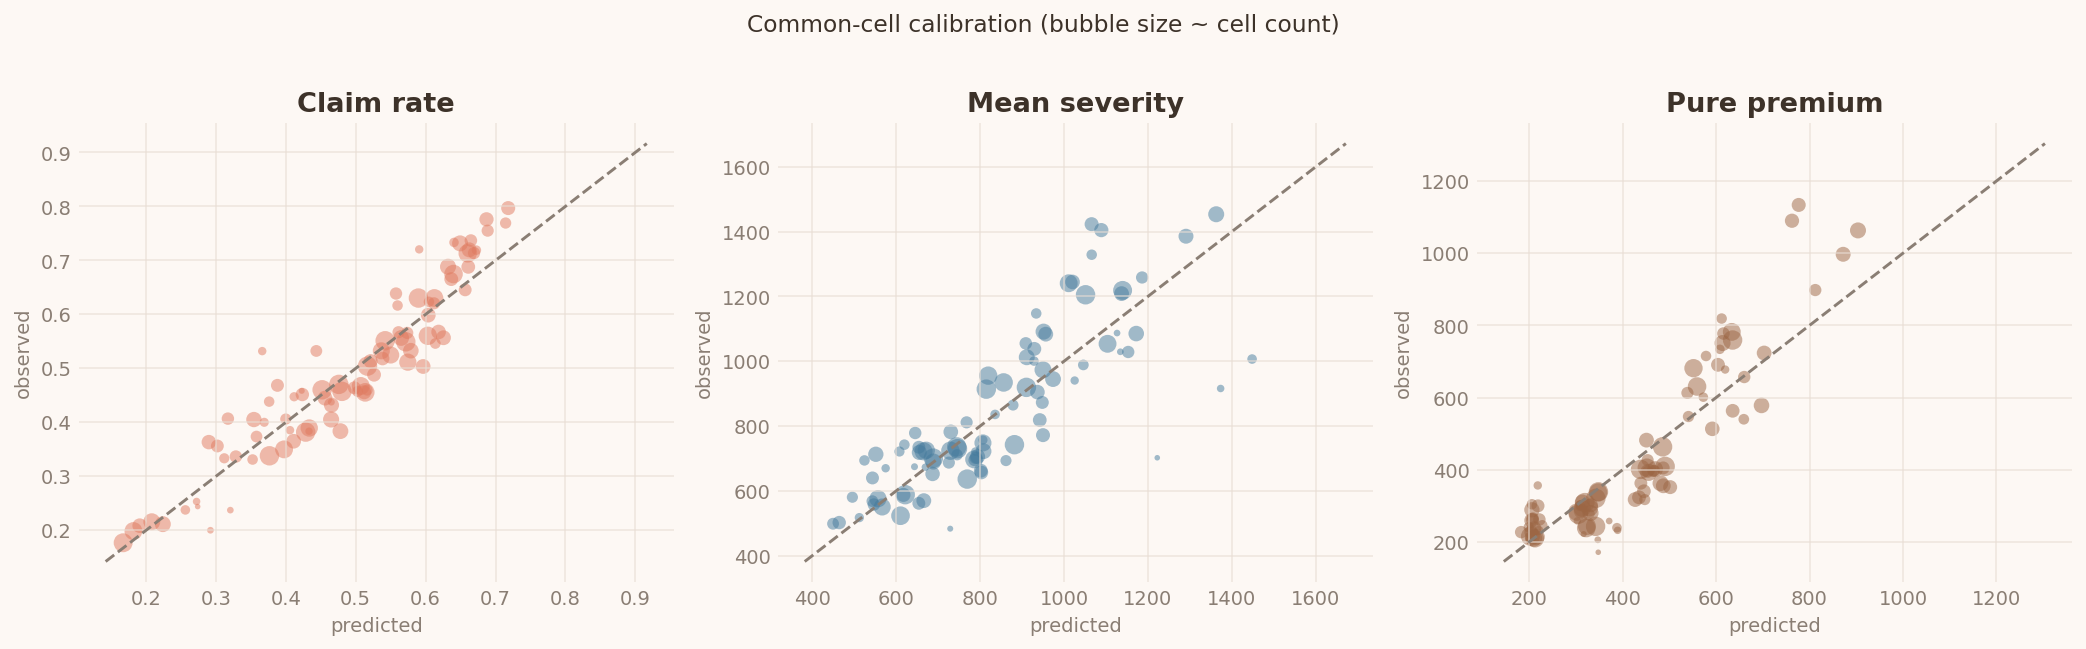

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, oc, pc, title, color in [
    (axes[0], "obs_rate", "pred_rate", "Claim rate", style.PRIMARY),
    (axes[1], "obs_sev", "pred_sev", "Mean severity", style.SECONDARY),
    (axes[2], "obs_pp", "pred_pp", "Pure premium", style.ACCENT),
]:
    sizes = cells_df["n_pol"].clip(upper=500) / 5
    ax.scatter(cells_df[pc], cells_df[oc], s=sizes, alpha=0.5,
               color=color, edgecolors="none")
    all_vals = pd.concat([cells_df[pc], cells_df[oc]])
    lims = [all_vals.min() * 0.85, all_vals.max() * 1.15]
    ax.plot(lims, lims, "--", color=style.TEXT_MUTED, lw=1.5)
    ax.set_xlabel("predicted"); ax.set_ylabel("observed")
    ax.set_title(title)

fig.suptitle("Common-cell calibration (bubble size ~ cell count)", y=1.02)
fig.tight_layout(); plt.show()

**Validation summary:** The combined model is supported by three
complementary checks:

1. **Temporal holdout** (Section 4.1): confirms year-stability and
   forward-looking validity (Freq AUC stable at ~0.69 across years)
2. **Random holdout** (Section 2): confirms generalisation (Freq AUC ~0.69,
   Sev MAE ~634)
3. **Common-cell calibration** (this section): confirms combined
   frequency × severity alignment at aggregate level (r ≈ 0.91)

This multi-layered validation design reflects the unlinked data structure:
since individual policies cannot be tracked across files, cell-level
calibration is the best available combined validation.

### 5.4 Portfolio balance check

In [27]:
calib = pure_premium.calibration_check(
    pp_df, observed_total_loss=sev_df[SEV_TARGET].sum(),
)
print(pd.Series(calib).round(2).to_string())
print(f"\n-> Predicted/observed ratio ~ 1.0 — well-calibrated at portfolio level.")

predicted_total_loss    10602746.11
observed_total_loss     10615726.00
ratio_pred_over_obs            1.00

-> Predicted/observed ratio ~ 1.0 — well-calibrated at portfolio level.


### 5.5 Loss concentration

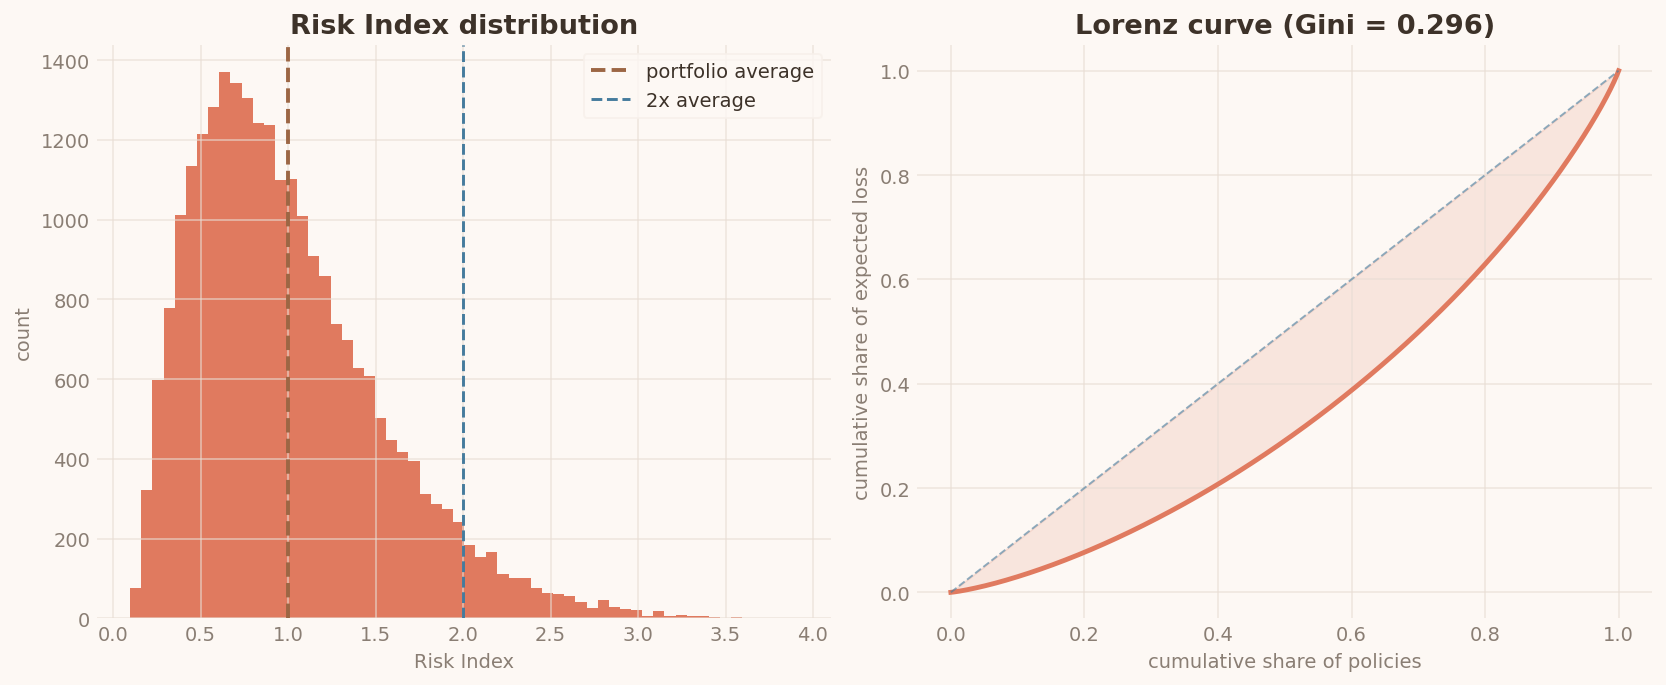

Policies above 2x average risk: 5.4%
Gini coefficient: 0.296


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Risk Index distribution
axes[0].hist(pp_df["risk_index"], bins=60, color=style.PRIMARY, edgecolor="none")
axes[0].axvline(1.0, color=style.ACCENT, ls="--", lw=2, label="portfolio average")
axes[0].axvline(2.0, color=style.SECONDARY, ls="--", lw=1.5, label="2x average")
axes[0].set_xlabel("Risk Index"); axes[0].set_ylabel("count")
axes[0].set_title("Risk Index distribution")
axes[0].legend(frameon=True, facecolor=style.BG, edgecolor=style.SURFACE)

# Lorenz curve
pop, cum = pure_premium.lorenz_curve(pp_df)
axes[1].fill_between(pop, cum, pop, alpha=0.15, color=style.PRIMARY)
axes[1].plot(pop, cum, lw=2.5, color=style.PRIMARY, label="portfolio")
axes[1].plot([0, 1], [0, 1], "--", color=style.SECONDARY, lw=1, alpha=0.6)
gini = 1 - 2 * float(np.trapezoid(cum, pop))
axes[1].set_xlabel("cumulative share of policies")
axes[1].set_ylabel("cumulative share of expected loss")
axes[1].set_title(f"Lorenz curve (Gini = {gini:.3f})")

fig.tight_layout(); plt.show()

pct_2x = (pp_df["risk_index"] > 2).mean() * 100
print(f"Policies above 2x average risk: {pct_2x:.1f}%")
print(f"Gini coefficient: {gini:.3f}")

### 5.6 Individual customer examples

To see how the two-part model works at the individual level, we pick
five illustrative customers and trace how the model scores them.
The same expected cost can arise from very different frequency/severity
combinations — and the right management action depends on *which*
combination applies.


In [29]:
np.random.seed(42)

# Attach model scores to raw covariates for readability
examples_df = freq_df[["age", "gender", "job", "carType", "carCat",
                       "density", "cover", "nYears"]].copy()
examples_df["p_claim"] = pp_df["p_claim"].values
examples_df["exp_severity"] = pp_df["exp_severity"].values
examples_df["pure_premium"] = pp_df["pure_premium"].values
examples_df["risk_index"] = pp_df["risk_index"].values

# Select five archetypes
med_p = pp_df["p_claim"].median()
med_s = pp_df["exp_severity"].median()

picks = pd.concat([
    examples_df[examples_df["risk_index"] > 2.3].sample(1),              # Very high risk
    examples_df[examples_df["risk_index"] < 0.3].sample(1),              # Very low risk
    examples_df[(pp_df["p_claim"] > med_p * 1.3) &
               (pp_df["exp_severity"] < med_s * 0.85)].sample(1),        # High freq / low sev
    examples_df[(pp_df["p_claim"] < med_p * 0.7) &
               (pp_df["exp_severity"] > med_s * 1.3)].sample(1),         # Low freq / high sev
    examples_df[(examples_df["risk_index"] > 0.95) &
               (examples_df["risk_index"] < 1.05)].sample(1),            # Average
])
picks.index = ["Very High Risk", "Very Low Risk",
               "Frequent but Cheap", "Rare but Costly", "Average"]

print("=== CUSTOMER PROFILES ===")
print(picks[["age", "gender", "job", "carType", "carCat","density", "cover", "nYears"]].to_string())
print("=== MODEL SCORES ===")
print(picks[["p_claim", "exp_severity", "pure_premium", "risk_index"]].round(2).to_string())


=== CUSTOMER PROFILES ===
                    age  gender         job carType  carCat     density cover  nYears
Very High Risk       26    Male  Unemployed       C   Small  253.619886     0       4
Very Low Risk        74  Female   Housewife       B   Large  137.887334     0       4
Frequent but Cheap   28    Male   Housewife       E  Medium  171.372936     1       9
Rare but Costly      73    Male     Retired       C   Large  139.283001     0      14
Average              32  Female    Employed       D   Large  148.995632     0       6
=== MODEL SCORES ===
                    p_claim  exp_severity  pure_premium  risk_index
Very High Risk         0.76       1421.39       1084.11        2.53
Very Low Risk          0.26        445.34        117.25        0.27
Frequent but Cheap     0.68        654.91        444.37        1.04
Rare but Costly        0.17       1047.82        182.69        0.43
Average                0.56        751.22        418.67        0.98


**Reading the table:**

- **Very High Risk** — young, unemployed, urban. Both frequency (76 %)
  and severity (1,400+ EUR) are high. Expected cost ~2.5x the average.
  → Underwriting review, repricing.

- **Very Low Risk** — older, female, moderate area. Low frequency (26 %)
  AND low severity (~445 EUR). Expected cost well below average.
  → Retain, standard renewal.

- **Frequent but Cheap** — claims often (~68 %) but each claim is
  inexpensive (~655 EUR). Total expected cost is near average.
  → The problem is *frequency*. Raising the deductible eliminates
  small claims.

- **Rare but Costly** — rarely claims (~17 %) but when it happens
  it is expensive (~1,050 EUR). Total expected cost is below average.
  → No pricing action needed, but a coverage/limit audit is sensible.

- **Average** — moderate frequency and severity. Right at the
  portfolio mean. → Standard renewal, no action.


---
## 6. Customer Profiling & Renewal Actions

The key value of the two-part model: it doesn't just rank customers —
it explains **why** a policy has high expected loss. A high-frequency /
low-severity customer needs a different renewal action than a
low-frequency / high-severity customer. We formalize this with a quadrant
decomposition.

### 6.1 Risk-tier summary

In [30]:
tiers = profiling.assign_tiers(pp_df)
tier_tbl = profiling.tier_summary(freq_df, pp_df, tiers)
print(tier_tbl.round(2).to_string())

               n  mean_pp  median_pp  mean_age  mean_carVal  mean_density  pct_of_portfolio  pct_of_total_loss
tier                                                                                                          
Low        12387   248.80     254.86     47.15     16276.47         90.86              50.0              29.07
Medium      7432   482.86     476.47     32.52     17083.58        138.49              30.0              33.85
High        3716   715.00     704.37     27.02     17383.78        189.33              15.0              25.06
Very High   1239  1029.32     992.74     23.42     18029.42        236.85               5.0              12.03


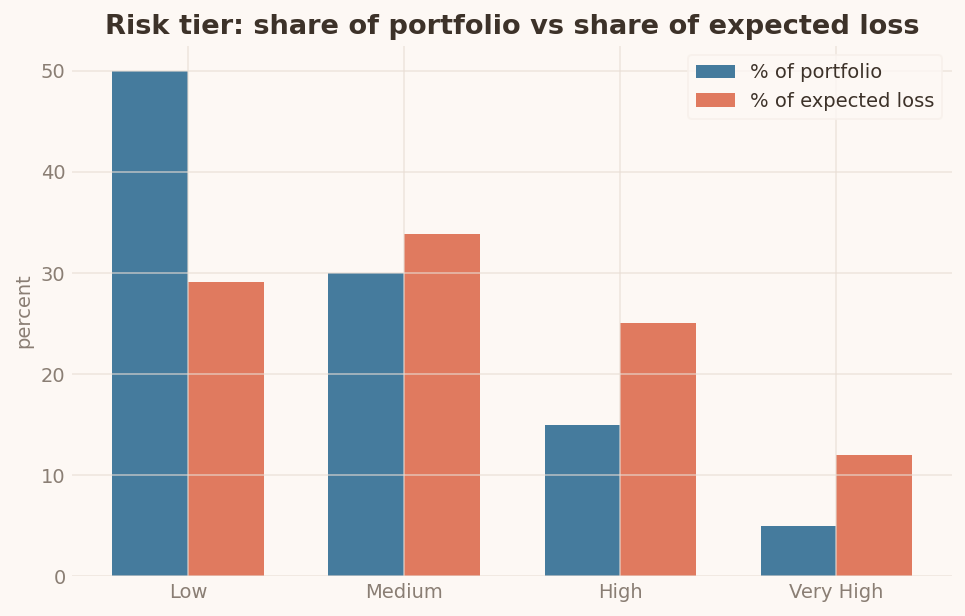

In [31]:
fig = plots.plot_tier_bars(tier_tbl); plt.show()

### 6.2 Frequency-severity quadrant decomposition

Each policy is classified by whether its predicted **frequency** and
**severity** are above or below a threshold, creating four quadrants
with distinct risk patterns. The choice of threshold matters: too low
and the "action" quadrants are too large to review; too high and they
miss too much loss.

We compare several threshold percentiles to find the one that best
balances **actionable group size**, **loss capture**, and **separation
between quadrant types**.


In [32]:
# --- Threshold comparison ---
threshold_results = []
for q in [0.50, 0.60, 0.70, 0.75, 0.80, 0.85]:
    t_p = pp_df["p_claim"].quantile(q)
    t_s = pp_df["exp_severity"].quantile(q)

    quad = (
        np.where(pp_df["p_claim"] > t_p, "High", "Low") + "/" +
        np.where(pp_df["exp_severity"] > t_s, "High", "Low")
    )
    hh = pp_df["pure_premium"][quad == "High/High"]
    ll = pp_df["pure_premium"][quad == "Low/Low"]

    # Between-quadrant explained variance (eta-squared)
    overall_var = pp_df["pure_premium"].var()
    quad_s = pd.Series(quad, index=pp_df.index)
    group_means = pp_df.groupby(quad_s)["pure_premium"].transform("mean")
    between_var = ((group_means - pp_mean) ** 2).mean()
    eta_sq = between_var / overall_var

    threshold_results.append({
        "quantile": f"P{int(q*100)}",
        "P(claim) >": round(t_p, 3),
        "E[sev] >": int(t_s),
        "HH size (%)": round(len(hh) / len(pp_df) * 100, 1),
        "HH loss share (%)": round(hh.sum() / pp_df["pure_premium"].sum() * 100, 1),
        "HH mean RI": round((hh.mean() / pp_mean), 2),
        "eta-squared": round(eta_sq, 3),
    })

threshold_df = pd.DataFrame(threshold_results).set_index("quantile")
print(threshold_df.to_string())
print()
print("eta-squared = fraction of total expected-loss variance explained by the")
print("four quadrants. Higher = more distinct groups.")


          P(claim) >  E[sev] >  HH size (%)  HH loss share (%)  HH mean RI  eta-squared
quantile                                                                               
P50            0.509       796         34.1               54.4        1.59        0.682
P60            0.551       862         25.3               43.8        1.73        0.705
P70            0.594       938         17.2               32.7        1.90        0.693
P75            0.617       982         13.5               27.1        2.00        0.672
P80            0.642      1032         10.1               21.3        2.12        0.633
P85            0.668      1093          6.8               15.3        2.27        0.578



eta-squared = fraction of total expected-loss variance explained by the
four quadrants. Higher = more distinct groups.


**Threshold selection: P75 (75th percentile for both axes)**

| Criterion | P50 (median) | P75 (selected) | P85 |
|---|---|---|---|
| HH group size | 34 % — too large to review | **13.5 %** — manageable queue | 6.8 % — misses too much |
| HH loss share | 54 % | **27 %** | 15 % |
| HH Risk Index | 1.59x | **2.00x** | 2.27x |
| eta-squared | 0.682 | **0.672** | 0.578 |

The P75 threshold is selected because:
1. The "High freq / High sev" group (13.5 %) is a **realistic underwriting
   review queue** — small enough to actually review at renewal.
2. Its Risk Index is **exactly 2.0x** the portfolio average — a clean,
   communicable threshold for management.
3. The "High freq / Low sev" and "Low freq / High sev" groups are
   well-separated (frequency gap = 0.27, severity gap = 323 EUR),
   enabling **distinct actions** for each.
4. The eta-squared (0.672) remains high — the quadrants still explain
   two-thirds of expected-loss variance.


In [33]:
# --- Apply P75 threshold ---
t_p = pp_df["p_claim"].quantile(0.75)
t_s = pp_df["exp_severity"].quantile(0.75)
print(f"Thresholds: P(claim) > {t_p:.3f},  E[severity] > {t_s:.0f} EUR")
print()

pp_df["freq_class"] = np.where(pp_df["p_claim"] > t_p, "High", "Low")
pp_df["sev_class"] = np.where(pp_df["exp_severity"] > t_s, "High", "Low")
pp_df["quadrant"] = pp_df["freq_class"] + " freq / " + pp_df["sev_class"] + " sev"

quad_order = [
    "Low freq / Low sev", "High freq / Low sev",
    "Low freq / High sev", "High freq / High sev",
]
pp_df["quadrant"] = pd.Categorical(
    pp_df["quadrant"], categories=quad_order, ordered=True,
)

quad_summ = pp_df.groupby("quadrant", observed=True).agg(
    n=("pure_premium", "count"),
    mean_EL=("pure_premium", "mean"),
    mean_RI=("risk_index", "mean"),
    mean_p=("p_claim", "mean"),
    mean_s=("exp_severity", "mean"),
)
quad_summ["pct_portfolio"] = (quad_summ["n"] / len(pp_df) * 100).round(1)
quad_summ["pct_loss"] = (
    pp_df.groupby("quadrant", observed=True)["pure_premium"].sum()
    / pp_df["pure_premium"].sum() * 100
).round(1)
print(quad_summ.round(2).to_string())


Thresholds: P(claim) > 0.617,  E[severity] > 982 EUR

                          n  mean_EL  mean_RI  mean_p   mean_s  pct_portfolio  pct_loss
quadrant                                                                               
Low freq / Low sev    15740   307.55     0.72    0.43   697.91           63.5      45.7
High freq / Low sev    2840   558.27     1.30    0.67   826.07           11.5      15.0
Low freq / High sev    2840   459.67     1.07    0.41  1148.68           11.5      12.3
High freq / High sev   3354   855.99     2.00    0.71  1204.70           13.5      27.1


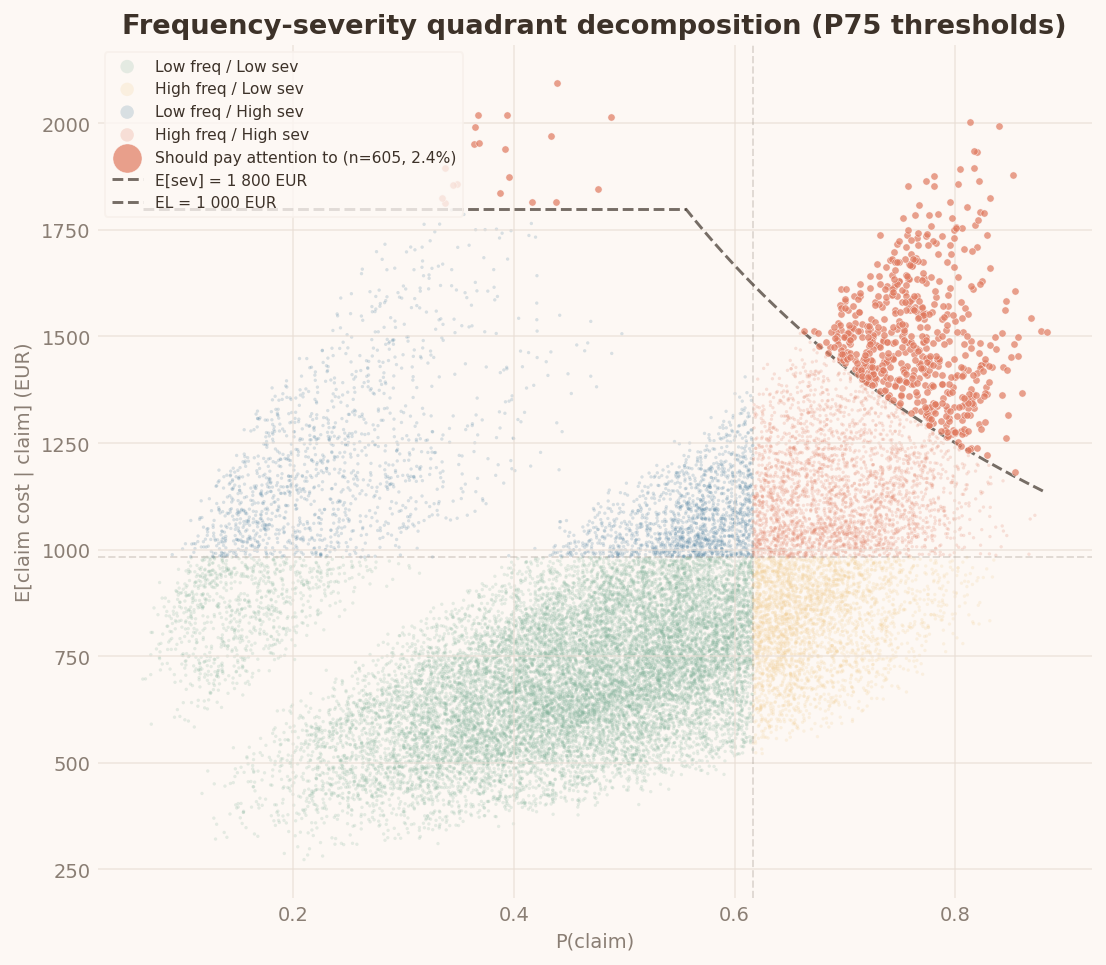

Attention group: 605 policies (2.4% of portfolio)
Mean EL in attention group: 1130 EUR
Mean RI in attention group: 2.64


In [34]:
fig, ax = plt.subplots(figsize=(8, 7))

cmap = {
    "Low freq / Low sev": style.PALETTE[1],
    "High freq / Low sev": style.PALETTE[2],
    "Low freq / High sev": style.PALETTE[3],
    "High freq / High sev": style.PALETTE[0],
}

attention = (pp_df["pure_premium"] > 1000) | (pp_df["exp_severity"] > 1800)
n_att = attention.sum()
pct_att = n_att / len(pp_df) * 100

for q in quad_order:
    m = (pp_df["quadrant"] == q) & ~attention
    ax.scatter(pp_df.loc[m, "p_claim"], pp_df.loc[m, "exp_severity"],
               s=3, alpha=0.20, color=cmap[q], label=q, edgecolors="none")

ax.scatter(pp_df.loc[attention, "p_claim"], pp_df.loc[attention, "exp_severity"],
           s=14, alpha=0.70, color=style.HIGHLIGHT, edgecolors="white",
           linewidths=0.3, zorder=5,
           label=f"Should pay attention to (n={n_att}, {pct_att:.1f}%)")

ax.axvline(t_p, color=style.TEXT_MUTED, ls="--", lw=1, alpha=0.25)
ax.axhline(t_s, color=style.TEXT_MUTED, ls="--", lw=1, alpha=0.25)

x_int = 1000 / 1800
x_lo = pp_df["p_claim"].min()
x_hi = pp_df["p_claim"].max()
ax.plot([x_lo, x_int], [1800, 1800], color=style.TEXT, ls="--", lw=1.5,
        alpha=0.7, label="E[sev] = 1 800 EUR")
x_hyp = np.linspace(x_int, x_hi, 300)
ax.plot(x_hyp, 1000 / x_hyp, color=style.TEXT, ls="--", lw=1.5,
        alpha=0.7, label="EL = 1 000 EUR")

ax.set_xlabel("P(claim)")
ax.set_ylabel("E[claim cost | claim] (EUR)")
ax.set_title("Frequency-severity quadrant decomposition (P75 thresholds)")
ax.legend(markerscale=4, frameon=True, facecolor=style.BG,
          edgecolor=style.SURFACE, fontsize=8)
fig.tight_layout(); plt.show()

print(f"Attention group: {n_att} policies ({pct_att:.1f}% of portfolio)")
print(f"Mean EL in attention group: {pp_df.loc[attention, "pure_premium"].mean():.0f} EUR")
print(f"Mean RI in attention group: {pp_df.loc[attention, "risk_index"].mean():.2f}")


### 6.3 Renewal action framework

The P75 quadrant decomposition assigns each policy to one of four action
categories. The threshold is set so that the "immediate action" group
(High freq / High sev) is 13.5 % of the portfolio — a realistic
underwriting review queue.

**Important:** These recommendations should be combined with current
premium adequacy assessment, claims history review, underwriting rules,
and customer-lifetime-value considerations. No policy should be
non-renewed based solely on model score.

| Quadrant | Size | Risk Index | What drives the cost | Recommended action |
|---|---|---|---|---|
| **High freq / High sev** | 13.5 % | 2.00x | Claims often AND each claim is expensive | **Immediate:** mandatory underwriting review; check premium adequacy; consider repricing + deductible increase + coverage adjustment; escalate only extreme cases for non-renewal review |
| **High freq / Low sev** | 11.5 % | 1.30x | Claims often but each claim is cheap | **High:** raise deductible to eliminate small claims; repair-network steering; moderate repricing |
| **Low freq / High sev** | 11.5 % | 1.07x | Rarely claims but expensive when they do | **Medium:** coverage/limit audit; verify vehicle valuation; no immediate repricing needed |
| **Low freq / Low sev** | 63.5 % | 0.72x | Low risk on both dimensions | **Standard:** retain; avoid excessive price increases that push them to competitors |

**Why the actions differ:** the "High freq / Low sev" and "Low freq /
High sev" groups have similar total expected cost (~1.2x average), but
the *intervention* is completely different. The first needs fewer claims
(higher deductible). The second needs smaller claims when they happen
(coverage limits). This distinction is only possible because frequency
and severity are modelled and thresholded separately.


### 6.4 Surrogate decision tree for profile communication

In [35]:
pp_df["top_risk"] = (
    pp_df["risk_index"] > pp_df["risk_index"].quantile(0.9)
).astype(int)

tree_X = preprocessing.build_design_matrix(freq_df)
tree = DecisionTreeClassifier(
    max_depth=3, min_samples_leaf=100, random_state=RANDOM_STATE,
)
tree.fit(tree_X, pp_df["top_risk"])

print("Decision rules for identifying high expected-loss customers:\n")
print(export_text(tree, feature_names=list(tree_X.columns), max_depth=3))
print(f"Tree accuracy: {tree.score(tree_X, pp_df['top_risk']):.1%}")

Decision rules for identifying high expected-loss customers:

|--- density <= 206.69
|   |--- job_Unemployed <= 0.50
|   |   |--- age <= 21.50
|   |   |   |--- class: 0
|   |   |--- age >  21.50
|   |   |   |--- class: 0
|   |--- job_Unemployed >  0.50
|   |   |--- age <= 26.50
|   |   |   |--- class: 0
|   |   |--- age >  26.50
|   |   |   |--- class: 0
|--- density >  206.69
|   |--- age <= 29.50
|   |   |--- cover_1 <= 0.50
|   |   |   |--- class: 1
|   |   |--- cover_1 >  0.50
|   |   |   |--- class: 0
|   |--- age >  29.50
|   |   |--- job_Unemployed <= 0.50
|   |   |   |--- class: 0
|   |   |--- job_Unemployed >  0.50
|   |   |   |--- class: 0

Tree accuracy: 93.5%


### 6.5 Factor breakdown across tiers

In [37]:
for f in ["gender", "carType", "carCat", "job", "cover", "uwYear"]:
    print(f"\n--- {f} (% of each tier) ---")
    print(profiling.tier_factor_profile(freq_df, tiers, f))


--- gender (% of each tier) ---
              Female  Male
pure_premium              
Low             41.6  58.4
Medium          30.4  69.6
High            23.4  76.6
Very High       15.5  84.5

--- carType (% of each tier) ---
                 A     B     C     D     E
pure_premium                              
Low           25.7  20.0  14.4  22.1  17.8
Medium        25.2  21.5  13.6  20.5  19.1
High          27.9  23.6  13.8  17.7  16.9
Very High     35.9  26.6  12.8  12.4  12.3

--- carCat (% of each tier) ---
              Small  Medium  Large
pure_premium                      
Low            22.8    36.4   40.8
Medium         36.3    37.1   26.6
High           41.5    36.6   21.9
Very High      42.6    37.5   19.9

--- job (% of each tier) ---
              Employed  Housewife  Retired  Self-employed  Unemployed
pure_premium                                                         
Low               29.5       24.5     15.8           23.6         6.6
Medium            39.3       2

### 6.6 Tier × Quadrant cross-tabulation

In [38]:
pp_df["tier"] = tiers.values
tier_quad = pd.crosstab(
    pp_df["tier"], pp_df["quadrant"], normalize="index",
) * 100
print("What quadrant do policies in each tier fall into (%):")
print(tier_quad.round(1).to_string())

What quadrant do policies in each tier fall into (%):
quadrant   Low freq / Low sev  High freq / Low sev  Low freq / High sev  High freq / High sev
tier                                                                                         
Low                      91.0                  0.4                  8.6                   0.0
Medium                   60.2                 26.1                 13.7                   0.0
High                      0.0                 22.7                 20.3                  57.0
Very High                 0.0                  0.0                  0.2                  99.8


In [39]:
top_profile = profiling.describe_top_segment(
    freq_df, pp_df, tiers, segment_label="Very High",
)
print(f"\n{'=' * 60}")
print(f"VERY HIGH TIER PROFILE (top 5 %)")
print(f"{'=' * 60}")
print(f"  Policies:              {top_profile['n_policies']:,}")
print(f"  Share of portfolio:    {top_profile['share_of_portfolio_pct']:.1f} %")
print(f"  Mean expected loss:    {top_profile['mean_pure_premium']:.0f} EUR")
print(f"  Risk Index:            {top_profile['ratio_to_overall_mean']:.1f}x")
print(f"\n  Typical profile:")
for k, v in top_profile["typical_profile"].items():
    print(f"    {k:>10s}: {v}")


VERY HIGH TIER PROFILE (top 5 %)
  Policies:              1,239
  Share of portfolio:    5.0 %
  Mean expected loss:    1029 EUR
  Risk Index:            2.4x

  Typical profile:
        uwYear: 2010 (61%)
        gender: Male (85%)
       carType: A (36%)
        carCat: Small (43%)
           job: Unemployed (63%)
         cover: 0 (88%)
           age: 23.4
        nYears: 4.0
        carVal: 18029.4
       density: 236.9


---
## 7. Conclusions & Recommendations

### 7.1 Executive summary

We estimated the **expected material-damage claim cost** for every policy
in the motor portfolio using a two-part actuarial model: a logistic GLM
for claim frequency and a Gamma GLM for claim severity. Because premium
and expense data are unavailable, **true profitability cannot be
measured**. Instead, we identify policies with high expected technical
loss — those most likely to be underpriced if premiums are not fully
risk-adjusted.

The combined model is well-calibrated (predicted/observed ≈ 1.00) and
validated through common-cell calibration (r ≈ 0.91), temporal
2009→2010 holdout, and a gradient-boosting challenger that confirms
ranking agreement (Spearman ≈ 0.88).

### 7.2 What "high expected loss" means in this analysis

> We cannot observe true profitability because premium and expense data
> are missing. We therefore identify high expected material-damage claim
> cost as a proxy for potential unprofitability. A two-part
> frequency-severity GLM is the primary model because it matches the
> unlinked data structure and is interpretable for management. The result
> is calibrated at portfolio level, validated at common risk-cell level,
> stable across underwriting years, and supported by a GBM challenger.
> The top-risk policies should be reviewed at renewal for premium
> adequacy, deductible/coverage changes, and only in extreme cases
> potential non-renewal.

### 7.3 Key findings

1. **Risk is concentrated:** the top 5 % of policies account for ~12 % of
   total expected loss, at ~2.4× the portfolio average.

2. **Typical high expected-loss profile:** young (~23 yr), male,
   unemployed, urban, no MD cover — predominantly in the High freq / High
   sev quadrant.

3. **Frequency and severity tell different stories:**
   - Young unemployed → high frequency AND high severity
   - Retired → low frequency but high severity when they do claim
   - Car type E → increases frequency but decreases severity
   - This is why the quadrant decomposition matters for action design.

4. **Models are robust:** stable across underwriting years, insensitive to
   gender exclusion, and confirmed by a gradient-boosting challenger.

5. **Severity discrimination is limited:** the GLM severity model ranks
   individual claims weakly (rank correlation ≈ −0.01), which is typical
   for heavy-tailed data with policy-level covariates. Frequency is the
   dominant driver of customer segmentation. The aggregate severity
   calibration is good, and the GBM challenger confirms similar
   pure-premium rankings.

### 7.4 Renewal action framework

| Risk group | Share | Risk Index | Recommended action |
|---|---|---|---|
| Very High (top 5 %) | 5 % | ~2.4× | Manual underwriting review; check premium adequacy; consider deductible, coverage, or pricing changes; escalate extreme cases for non-renewal review |
| High (80–95th pctl) | 15 % | ~1.7× | Targeted repricing or deductible adjustment, subject to current premium adequacy |
| Medium (50–80th) | 30 % | ~1.1× | Monitor; review if premium is below technical price |
| Low (bottom 50 %) | 50 % | ~0.6× | Retain; avoid excessive price increases |

### 7.5 Caveats & limitations

- **No premium data** — we rank by expected loss, not loss ratio. Adding
  premiums would sharpen the analysis immediately.
- **No individual linkage** — frequency and severity modelled on separate
  datasets. Residual dependence beyond shared covariates is not captured.
  Combined validation is therefore performed at cell level, not per-policy.
- **Gender & EU law** — gender was retained in the diagnostic model for
  portfolio understanding. The gender-free model should be used for any
  operational renewal decisions. Its performance loss is negligible
  (< 0.5 ppt AUC, < 2 EUR MAE).
- **~50 % claim rate** — if the dataset is balanced/sampled, absolute
  probabilities require recalibration before deployment. Rankings remain
  valid.
- **Severity tail** — GLMs have weak individual-level severity rank
  discrimination. This is common with heavy-tailed data and policy-level
  covariates only. The GBM challenger improves severity ranking modestly
  and serves as a sensitivity check on final pure-premium rankings.

### 7.6 Final executive table

| Question | Answer |
|---|---|
| Can we measure true unprofitability? | No — no premium or expense data available |
| What do we estimate instead? | Expected material-damage claim cost per policy |
| Recommended model | Two-part GLM (logistic + Gamma), with GBM challenger |
| Validation | Portfolio balance ≈ 1.00; common-cell r ≈ 0.91; stable across years |
| Highest-risk segment | Top 5 %, approximately 2.4× average expected loss |
| Operational model for EU | Gender-free specification (negligible performance loss) |
| Management action | Manual renewal review; pricing/deductible/coverage assessment; non-renewal only in extreme cases after underwriting review |

---
*Generated by the v5 analysis pipeline. Primary model: two-part GLM.
Challenger: gradient-boosted trees. All code in `src/` and this notebook.*